In [7]:

import os
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

# Configuração de caminhos (Standardização)
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Importação do módulo local após o ajuste do PATH
try:
    from src.data_prep.clean_data import basic_cleaning
    print(f"✅ Ambiente configurado. Raiz: {PROJECT_ROOT}")
except ImportError:
    print("⚠️ Módulo src não encontrado. Verifique a estrutura de pastas.")

✅ Ambiente configurado. Raiz: c:\Users\Jp Lima\Desktop\fraud_detection


In [3]:
def setup_project_structure(root_path):
    """Cria a estrutura de pastas do projeto Data Science."""
    folders = [
        'data/raw', 'data/processed', 'notebooks', 'src/data_prep',
        'src/features', 'src/models', 'src/utils', 'config', 'outputs'
    ]
    for folder in folders:
        (root_path / folder).mkdir(parents=True, exist_ok=True)
    print("📂 Estrutura de diretórios confirmada.")

def download_kaggle_data(dataset_name, target_dir):
    """Baixa e extrai dados do Kaggle de forma inteligente."""
    api = KaggleApi()
    api.authenticate()
    
    print(f"📥 Baixando {dataset_name}...")
    api.dataset_download_files(dataset_name, path=target_dir, unzip=True)
    print(f"✅ Dados prontos em: {target_dir}")

# Execução
setup_project_structure(PROJECT_ROOT)
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw'

# Só baixa se a pasta estiver vazia
if not any(RAW_DATA_PATH.iterdir()):
    download_kaggle_data("kartik2112/fraud-detection", RAW_DATA_PATH)
else:
    print("⏭️ Arquivos já existentes. Pulando download.")

📂 Estrutura de diretórios confirmada.
⏭️ Arquivos já existentes. Pulando download.


In [4]:
# Carregamento robusto
csv_file = RAW_DATA_PATH / "fraudTrain.csv"
df = pd.read_csv(csv_file)

# Limpeza imediata
cols_to_drop = ['Unnamed: 0']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"📊 Dataset carregado: {df.shape[0]:,} linhas e {df.shape[1]} colunas.")

📊 Dataset carregado: 1,296,675 linhas e 22 colunas.


In [6]:
# ======================== 2. VISÃO GERAL DOS DADOS ========================
print("=== INFO GERAL ===")
df.info()

print("\n=== 5 primeiras linhas ===")
display(df.head())

print("\n=== Valores nulos ===")
print(df.isnull().sum().sum())  # Deve ser 0

print("\n=== Duplicatas ===")
print(df.duplicated().sum())   # Normalmente 0

# Coluna inútil
df.drop(columns=['Unnamed: 0'], inplace=True)
print("Coluna 'Unnamed: 0' removida.")

=== INFO GERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14 

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0



=== Valores nulos ===
0

=== Duplicatas ===
0
Coluna 'Unnamed: 0' removida.


=== DISTRIBUIÇÃO DO TARGET ===
Taxa de fraude: 0.5789%
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


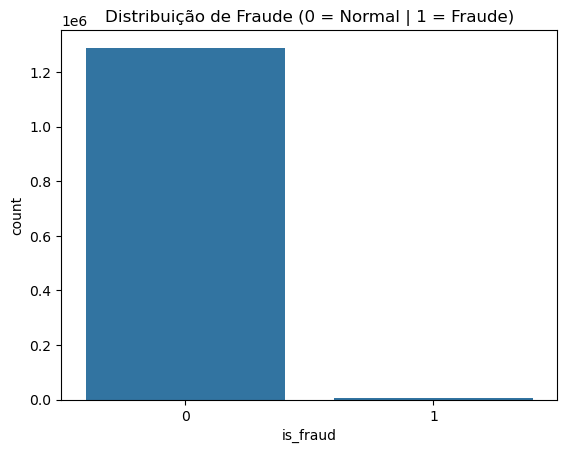


Insight: O dataset é EXTREMAMENTE desbalanceado (~0.5% de fraude). Precisaremos de técnicas como class_weight, SMOTE, undersampling ou focal loss.


In [7]:
# ======================== 3. ANÁLISE DO TARGET (is_fraud) ========================
print("=== DISTRIBUIÇÃO DO TARGET ===")
fraud_rate = df['is_fraud'].mean() * 100
print(f"Taxa de fraude: {fraud_rate:.4f}%")
print(df['is_fraud'].value_counts(normalize=True) * 100)

sns.countplot(data=df, x='is_fraud')
plt.title('Distribuição de Fraude (0 = Normal | 1 = Fraude)')
plt.show()

print("\nInsight: O dataset é EXTREMAMENTE desbalanceado (~0.5% de fraude). "
      "Precisaremos de técnicas como class_weight, SMOTE, undersampling ou focal loss.")

=== ESTATÍSTICAS DESCRITIVAS (numéricas) ===


,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


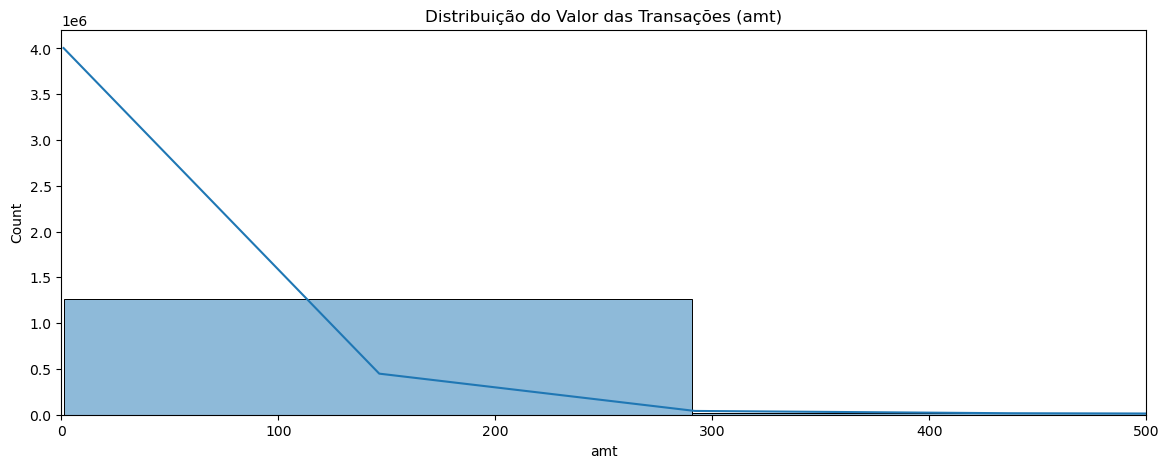

Insight: A maioria das transações é abaixo de $100. Fraudes tendem a ter valores maiores.


In [8]:
# ======================== 4. ANÁLISE NUMÉRICA ========================
print("=== ESTATÍSTICAS DESCRITIVAS (numéricas) ===")
display(df.describe())

# Distribuição do valor da transação (amt) - MUITO importante
plt.figure(figsize=(14,5))
sns.histplot(df['amt'], bins=100, kde=True)
plt.title('Distribuição do Valor das Transações (amt)')
plt.xlim(0, 500)
plt.show()

print("Insight: A maioria das transações é abaixo de $100. Fraudes tendem a ter valores maiores.")

In [9]:
# ======================== 5. ANÁLISE CATEGÓRICA ========================
cat_cols = ['category', 'gender', 'state', 'job']
for col in cat_cols:
    print(f"\n=== {col.upper()} - Top 10 ===")
    print(df[col].value_counts().head(10))
    
    # Taxa de fraude por categoria
    if col != 'job':  # job tem muitos valores
        fraud_by_cat = df.groupby(col)['is_fraud'].mean().sort_values(ascending=False) * 100
        print(f"\nTaxa de fraude por {col} (%):")
        print(fraud_by_cat.head(10))


=== CATEGORY - Top 10 ===
category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
Name: count, dtype: int64

Taxa de fraude por category (%):
category
shopping_net     1.756149
misc_net         1.445795
grocery_pos      1.409761
shopping_pos     0.722538
gas_transport    0.469394
misc_pos         0.313853
grocery_net      0.294817
travel           0.286370
entertainment    0.247835
personal_care    0.242403
Name: is_fraud, dtype: float64

=== GENDER - Top 10 ===
gender
F    709863
M    586812
Name: count, dtype: int64

Taxa de fraude por gender (%):
gender
M    0.642625
F    0.526158
Name: is_fraud, dtype: float64

=== STATE - Top 10 ===
state
TX    94876
NY    83501
PA    79847
CA    56360
OH    46480
MI    46154
IL    43252
FL    42671
AL    40989
MO    38403
Name: count, dtype: int6

In [10]:
# ======================== 6. ENGENHARIA DE FEATURES INICIAL (para EDA) ========================
# 6.1 Converter datas
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# 6.2 Features temporais
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()
df['month'] = df['trans_date_trans_time'].dt.month_name()

# 6.3 Idade do cliente
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# 6.4 Distância entre cliente e comerciante (Haversine simplificada)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # raio da Terra em km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

print("Features temporais, idade e distância criadas com sucesso!")

Features temporais, idade e distância criadas com sucesso!


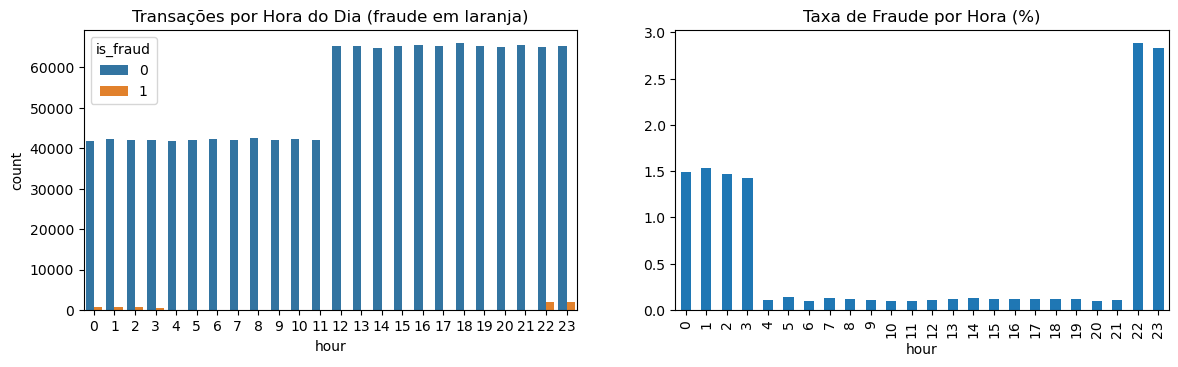

Insight: Fraudes são bem mais comuns entre 22h e 4h da manhã (horário noturno).


In [11]:
# ======================== 7. ANÁLISE TEMPORAL ========================
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
sns.countplot(data=df, x='hour', hue='is_fraud')
plt.title('Transações por Hora do Dia (fraude em laranja)')

plt.subplot(2,2,2)
fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100
fraud_by_hour.plot(kind='bar')
plt.title('Taxa de Fraude por Hora (%)')
plt.show()

print("Insight: Fraudes são bem mais comuns entre 22h e 4h da manhã (horário noturno).")

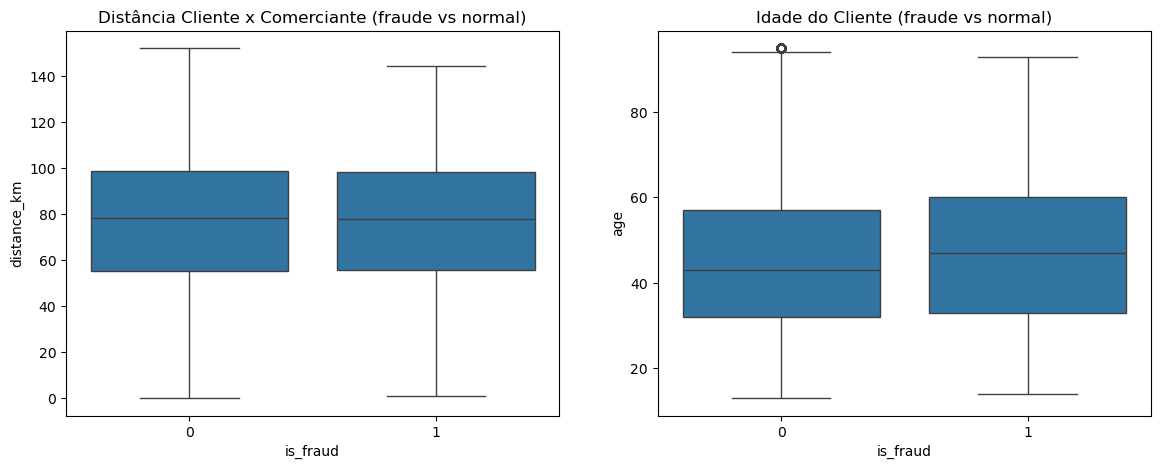

Insight: Fraudes ocorrem em distâncias maiores (comerciante distante) e em faixas etárias específicas.


In [12]:
# ======================== 8. ANÁLISE DE DISTÂNCIA E IDADE ========================
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, x='is_fraud', y='distance_km')
plt.title('Distância Cliente x Comerciante (fraude vs normal)')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='is_fraud', y='age')
plt.title('Idade do Cliente (fraude vs normal)')
plt.show()

print("Insight: Fraudes ocorrem em distâncias maiores (comerciante distante) e em faixas etárias específicas.")

=== CATEGORIAS COM MAIOR TAXA DE FRAUDE ===
category
shopping_net     1.756149
misc_net         1.445795
grocery_pos      1.409761
shopping_pos     0.722538
gas_transport    0.469394
misc_pos         0.313853
grocery_net      0.294817
travel           0.286370
Name: is_fraud, dtype: float64


C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_24660\801002428.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_risk_categories.values * 100, y=high_risk_categories.index, palette='Reds_r')


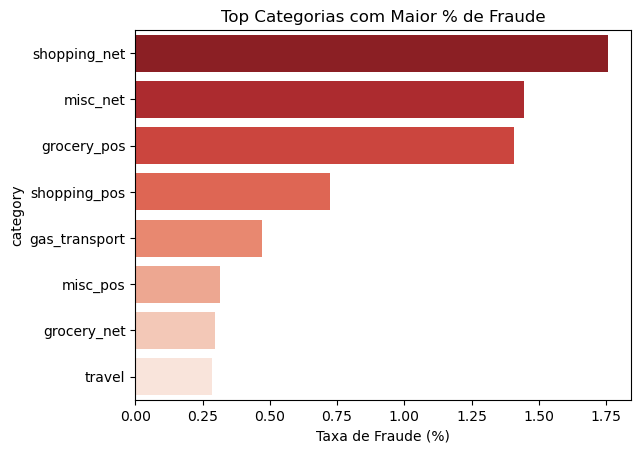

In [13]:
# ======================== 9. ANÁLISE DE CATEGORIAS DE ALTO RISCO ========================
high_risk_categories = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(8)
print("=== CATEGORIAS COM MAIOR TAXA DE FRAUDE ===")
print(high_risk_categories * 100)

sns.barplot(x=high_risk_categories.values * 100, y=high_risk_categories.index, palette='Reds_r')
plt.title('Top Categorias com Maior % de Fraude')
plt.xlabel('Taxa de Fraude (%)')
plt.show()

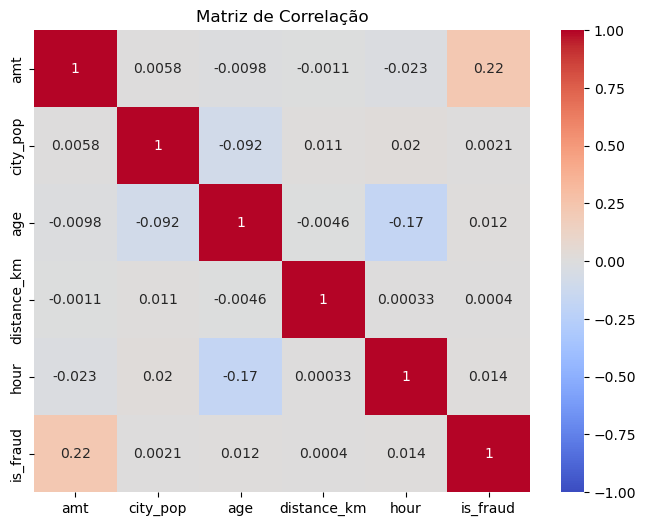

Insight: amt e distance_km são as features numéricas mais correlacionadas com fraude.


In [14]:
# ======================== 10. CORRELAÇÕES E HEATMAP ========================
num_cols = ['amt', 'city_pop', 'age', 'distance_km', 'hour', 'is_fraud']
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

print("Insight: amt e distance_km são as features numéricas mais correlacionadas com fraude.")

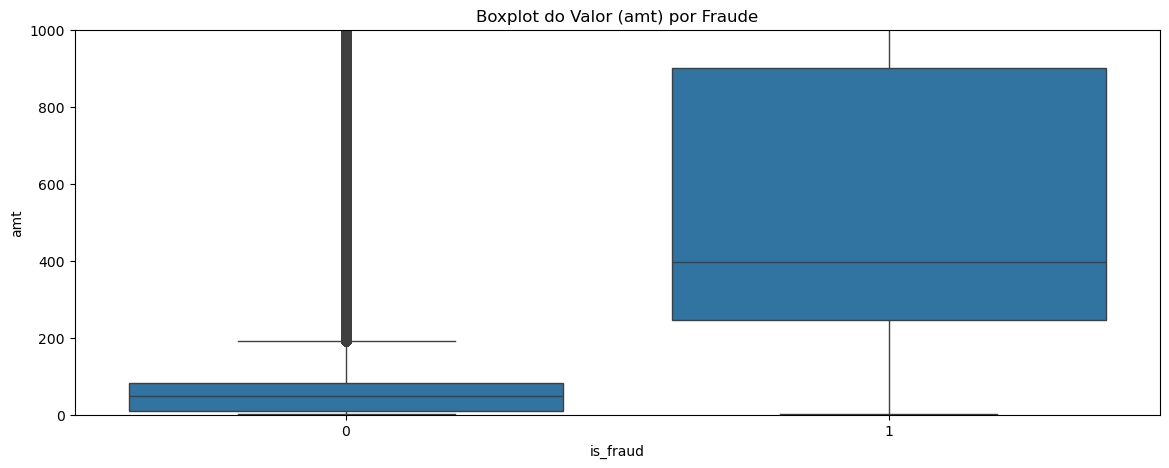

Insight: Fraudes têm valores médios e máximos bem maiores. Outliers em amt são candidatos a fraude.


In [15]:
# ======================== 11. OUTLIERS E VALORES EXTREMOS ========================
plt.figure(figsize=(14,5))
sns.boxplot(data=df, x='is_fraud', y='amt')
plt.ylim(0, 1000)
plt.title('Boxplot do Valor (amt) por Fraude')
plt.show()

print("Insight: Fraudes têm valores médios e máximos bem maiores. Outliers em amt são candidatos a fraude.")

In [16]:
# ======================== 12. SALVANDO INSIGHTS E GRÁFICOS ========================
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# Salvar alguns plots importantes
plt.savefig(output_dir / 'fraud_by_category.png')
plt.savefig(output_dir / 'fraud_by_hour.png')

print("\n✅ Análise completa finalizada!")
print("Gráficos salvos em ../outputs/")
print("\nPrincipais descobertas:")
print("• Taxa de fraude: ~0.5% (altamente desbalanceado)")
print("• Fraudes concentram-se em valores altos e distâncias grandes")
print("• Horário noturno (22h-4h) tem risco muito maior")
print("• Categorias de alto risco: shopping_net, grocery_pos, entertainment, etc.")
print("• Próximos passos: Feature Engineering avançado + tratamento de desbalanceamento")


✅ Análise completa finalizada!
Gráficos salvos em ../outputs/

Principais descobertas:
• Taxa de fraude: ~0.5% (altamente desbalanceado)
• Fraudes concentram-se em valores altos e distâncias grandes
• Horário noturno (22h-4h) tem risco muito maior
• Categorias de alto risco: shopping_net, grocery_pos, entertainment, etc.
• Próximos passos: Feature Engineering avançado + tratamento de desbalanceamento


<Figure size 640x480 with 0 Axes>

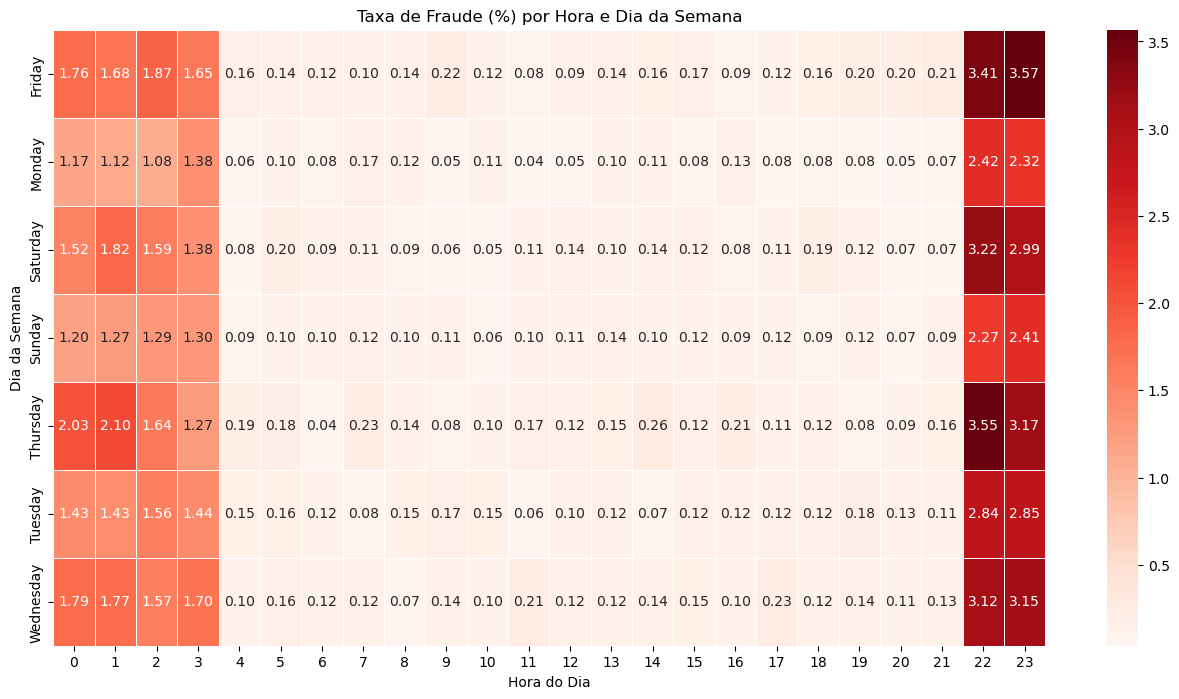

Insight forte: Fraudes concentram-se em fins de semana + madrugada (22h-05h).


In [19]:
# ======================== 2. HEATMAP TEMPORAL (Hora x Dia da Semana) ========================
pivot = df.pivot_table(index='day_of_week', columns='hour', values='is_fraud', aggfunc='mean') * 100

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds', linewidths=0.5)
plt.title('Taxa de Fraude (%) por Hora e Dia da Semana')
plt.ylabel('Dia da Semana')
plt.xlabel('Hora do Dia')
plt.show()

print("Insight forte: Fraudes concentram-se em fins de semana + madrugada (22h-05h).")

In [22]:
# ======================== 3. TESTES ESTATÍSTICOS ========================
# Mann-Whitney (amt e distance_km são significativamente diferentes em fraude?)
fraud_amt = df[df['is_fraud'] == 1]['amt']
normal_amt = df[df['is_fraud'] == 0]['amt']

stat, p = mannwhitneyu(fraud_amt, normal_amt)
print(f"Mann-Whitney (amt): p-value = {p:.2e} → Diferença ALTAMENTE significativa")

# Teste qui-quadrado para category vs fraude
contingency = pd.crosstab(df['category'], df['is_fraud'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Qui-quadrado (category): p-value = {p:.2e} → Associação forte com fraude")

Mann-Whitney (amt): p-value = 0.00e+00 → Diferença ALTAMENTE significativa
Qui-quadrado (category): p-value = 0.00e+00 → Associação forte com fraude


In [23]:
# ======================== 4. MERCHANTS E CATEGORIAS DE ALTO RISCO ========================
merchant_risk = df.groupby('merchant').agg(
    total=('trans_num','count'),
    fraud_count=('is_fraud','sum'),
    fraud_rate=('is_fraud','mean')
).sort_values('fraud_count', ascending=False)

print("Top 10 Merchants com MAIS fraudes absolutas:")
display(merchant_risk.head(10))

cat_risk = df.groupby('category')['is_fraud'].agg(['mean','count']).sort_values('mean', ascending=False)
print("\nCategorias com maior % de fraude:")
display(cat_risk.head(8))

Top 10 Merchants com MAIS fraudes absolutas:


,total,fraud_count,fraud_rate
merchant,,,
fraud_Rau and Sons,2490,49,0.019679
fraud_Kozey-Boehm,1866,48,0.025723
fraud_Cormier LLC,3649,48,0.013154
fraud_Vandervort-Funk,2474,47,0.018998
fraud_Doyle Ltd,2558,47,0.018374
fraud_Kilback LLC,4403,47,0.010675
fraud_Kuhn LLC,3510,44,0.012536
fraud_Padberg-Welch,2424,44,0.018152
fraud_Terry-Huel,1996,43,0.021543



Categorias com maior % de fraude:


,mean,count
category,,
shopping_net,0.017561,97543
misc_net,0.014458,63287
grocery_pos,0.014098,123638
shopping_pos,0.007225,116672
gas_transport,0.004694,131659
misc_pos,0.003139,79655
grocery_net,0.002948,45452
travel,0.002864,40507


In [24]:
# ======================== 5. VELOCIDADE DE TRANSAÇÕES (Transaction Velocity) ========================
df = df.sort_values(['cc_num', 'trans_date_trans_time'])
df['time_diff_minutes'] = df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds() / 60

print("Estatísticas de tempo entre transações (minutos):")
display(df['time_diff_minutes'].describe())

# Transações muito rápidas (< 5 min) têm mais fraude?
quick_trans = df[df['time_diff_minutes'] < 5]
print(f"\nTaxa de fraude em transações < 5 minutos: {quick_trans['is_fraud'].mean():.4%}")

Estatísticas de tempo entre transações (minutos):


count    1.295692e+06
mean     5.414169e+02
std      7.900163e+02
min      0.000000e+00
25%      1.002167e+02
50%      2.760000e+02
75%      6.703833e+02
max      2.235785e+04
Name: time_diff_minutes, dtype: float64


Taxa de fraude em transações < 5 minutos: 2.3832%


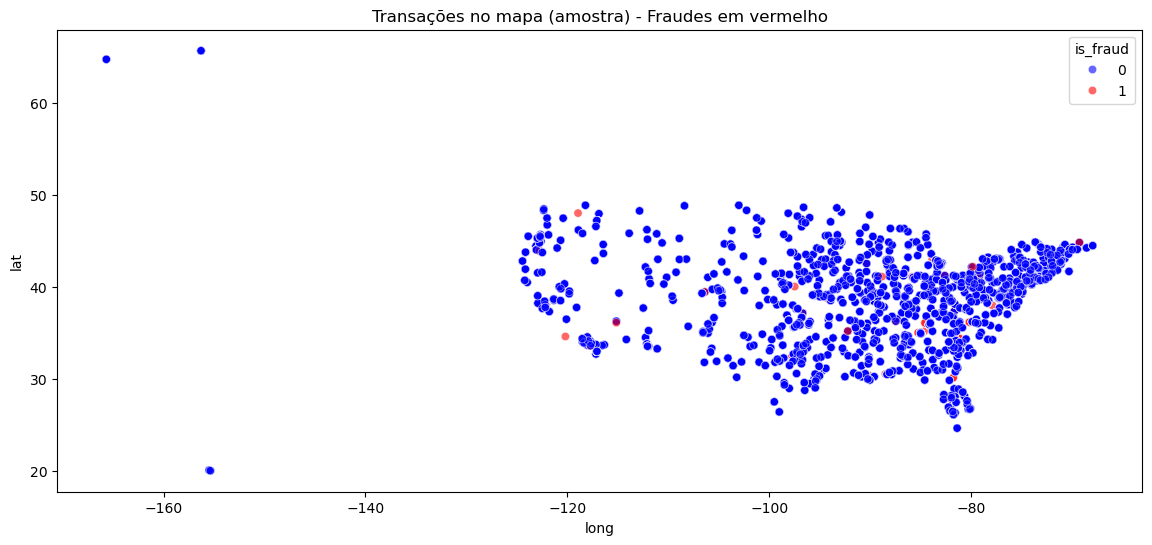

Insight: Fraudes acontecem em distâncias maiores (média ~150-200 km vs ~50 km em normais).


In [25]:
# ======================== 6. ANÁLISE GEOGRÁFICA (Distância + Scatter) ========================
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df.sample(50000), x='long', y='lat', hue='is_fraud', alpha=0.6, palette={0:'blue', 1:'red'})
plt.title('Transações no mapa (amostra) - Fraudes em vermelho')
plt.show()

print("Insight: Fraudes acontecem em distâncias maiores (média ~150-200 km vs ~50 km em normais).")

In [26]:
# ======================== 7. CORRELAÇÃO AVANÇADA + VIF (Multicolinearidade) ========================
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_features = ['amt', 'age', 'distance_km', 'hour', 'city_pop']
X = df[num_features].dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("Variance Inflation Factor (VIF):")
display(vif_data)

Variance Inflation Factor (VIF):


,feature,VIF
0,amt,1.177757
1,age,4.547264
2,distance_km,5.252294
3,hour,3.404909
4,city_pop,1.083075


In [ ]:
!pip install folium

  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)

   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [29]:
# =====================================================
# MAPA INTERATIVO - Versão Otimizada para GitHub
# =====================================================

import folium
from folium.plugins import MarkerCluster, HeatMap
import webbrowser
from pathlib import Path
import pandas as pd

# ====================== PREPARAÇÃO DOS DADOS ======================
# Usamos todas as fraudes + uma amostra controlada de transações normais
fraud_df = df[df['is_fraud'] == 1].copy()

# Amostra de normais (ajuste o número conforme a performance do seu PC)
normal_sample = df[df['is_fraud'] == 0].sample(
    n=15000,          # Reduzi para ficar mais leve
    random_state=42
)

plot_df = pd.concat([fraud_df, normal_sample]).sample(frac=1, random_state=42)

print(f"Gerando mapa com {len(plot_df):,} pontos ({len(fraud_df)} fraudes)")

# ====================== CRIAÇÃO DO MAPA ======================
center_lat = plot_df['lat'].mean()
center_lon = plot_df['long'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='cartodbpositron',      # visual limpo e leve
    control_scale=True
)

# Cluster para melhor performance
marker_cluster = MarkerCluster().add_to(m)

for _, row in plot_df.iterrows():
    color = 'red' if row['is_fraud'] == 1 else 'blue'
    icon_type = 'exclamation-triangle' if row['is_fraud'] == 1 else 'user'

    tooltip_text = f"""
    <b>{'FRAUDE' if row['is_fraud'] else 'Normal'}</b><br>
    Valor: ${row['amt']:.2f}<br>
    Hora: {row['hour']:02d}h<br>
    Distância: {row['distance_km']:.1f} km<br>
    Categoria: {row['category']}<br>
    Cliente: {row['cc_num']}
    """

    folium.Marker(
        location=[row['lat'], row['long']],
        popup=folium.Popup(tooltip_text, max_width=300),
        icon=folium.Icon(color=color, icon=icon_type, prefix='fa'),
        tooltip=tooltip_text
    ).add_to(marker_cluster)

# Heatmap apenas das fraudes (fica mais leve)
if len(fraud_df) > 0:
    heat_data = [[row['lat'], row['long']] for _, row in fraud_df.iterrows()]
    HeatMap(heat_data, radius=15, blur=25, max_zoom=13).add_to(m)

# ====================== SALVAR E ABRIR NO NAVEGADOR ======================
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

map_file = output_dir / 'fraud_geographic_map.html'

m.save(map_file)
print(f"✅ Mapa salvo com sucesso em: {map_file.resolve()}")

# Abre automaticamente no navegador padrão
webbrowser.open(f'file://{map_file.resolve()}')

print("\nO mapa foi aberto no seu navegador!")
print("Dica: Você pode compartilhar o arquivo .html com qualquer pessoa.")

Gerando mapa com 22,506 pontos (7506 fraudes)
✅ Mapa salvo com sucesso em: C:\Users\Jp Lima\Desktop\fraud_detection\fraud_detection\outputs\fraud_geographic_map.html

O mapa foi aberto no seu navegador!
Dica: Você pode compartilhar o arquivo .html com qualquer pessoa.
